# Jackson Crow Kaggle — NASDAQ stocks + ETFs quick look

Source: per-ticker CSVs in `stocks/` and `etfs/` plus `symbols_valid_meta.csv` (daily OHLCV / Adj Close, through ~April 2020).

In [11]:
from collections import defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Windows reserved names (PRN, CON, ...) need the \\?\ prefix to open as files
def load_csv(p, **kw):
    return pd.read_csv(rf"\\?\{Path(p).resolve()}", **kw)

meta = load_csv("symbols_valid_meta.csv")
aapl = load_csv("stocks/AAPL.csv", parse_dates=["Date"])
display(meta.head())
aapl.head()

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


## Index scan (all tickers)

In [12]:
idx_rows = []
year_tickers = defaultdict(set)
year_records = defaultdict(int)

for kind in ("stocks", "etfs"):
    for p in Path(kind).glob("*.csv"):
        dates = load_csv(p, usecols=["Date"])["Date"]
        idx_rows.append(
            {
                "Ticker": p.stem,
                "Kind": kind,
                "rows": len(dates),
                "first": dates.iloc[0],
                "last": dates.iloc[-1],
            }
        )
        years = dates.str[:4]
        for y, n in years.value_counts().items():
            yi = int(y)
            year_records[yi] += int(n)
            year_tickers[yi].add(p.stem)

idx = pd.DataFrame(idx_rows)
idx["first"] = pd.to_datetime(idx["first"])
idx["last"] = pd.to_datetime(idx["last"])
by_year = pd.DataFrame(
    {
        "n_tickers": {y: len(s) for y, s in year_tickers.items()},
        "n_records": year_records,
    }
).sort_index()
print(f"indexed files={len(idx):,}  rows={idx['rows'].sum():,}")
print(f"date range: {idx['first'].min().date()} → {idx['last'].max().date()}")
idx.head()

indexed files=8,049  rows=28,151,758
date range: 1962-01-02 → 2020-04-02


,Ticker,Kind,rows,first,last
0,A,stocks,5124,1999-11-18,2020-04-01
1,AA,stocks,14663,1962-01-02,2020-04-01
2,AACG,stocks,261,2019-03-11,2020-04-01
3,AAL,stocks,3653,2005-09-27,2020-04-01
4,AAMC,stocks,1837,2012-12-13,2020-04-01


## Granularity

In [13]:
g = aapl.sort_values("Date")
print(f"AAPL rows={len(g):,}  unique dates={g['Date'].nunique():,}  dups={g['Date'].duplicated().sum()}")
print(f"any non-midnight time: {(g['Date'].dt.normalize() != g['Date']).any()}")

gaps = g["Date"].diff().dt.days.dropna()
print("\ngap days between consecutive AAPL bars:")
display(gaps.value_counts().head(15).to_frame("count"))

print("\nrows by weekday (0=Mon … 6=Sun):")
display(g["Date"].dt.dayofweek.value_counts().sort_index().to_frame("rows"))

AAPL rows=9,909  unique dates=9,909  dups=0
any non-midnight time: False

gap days between consecutive AAPL bars:


,count
Date,
1.0,7763
3.0,1805
4.0,243
2.0,94
5.0,2
7.0,1



rows by weekday (0=Mon … 6=Sun):


,rows
Date,
0,1875
1,2031
2,2030
3,1992
4,1981


## Universe coverage

,Ticker,Kind,rows,first,last,span_days
901,CAT,stocks,14665,1962-01-02,2020-04-01,21274
3002,KO,stocks,14664,1962-01-02,2020-04-01,21274
3449,MO,stocks,14664,1962-01-02,2020-04-01,21274
1582,DTE,stocks,14663,1962-01-02,2020-04-01,21274
4156,PG,stocks,14663,1962-01-02,2020-04-01,21274
1655,ED,stocks,14663,1962-01-02,2020-04-01,21274
2009,FL,stocks,14663,1962-01-02,2020-04-01,21274
1494,DIS,stocks,14663,1962-01-02,2020-04-01,21274
1384,CVX,stocks,14663,1962-01-02,2020-04-01,21274
535,BA,stocks,14663,1962-01-02,2020-04-01,21274


,files,rows
Kind,,
etfs,2165,3954316
stocks,5884,24197442


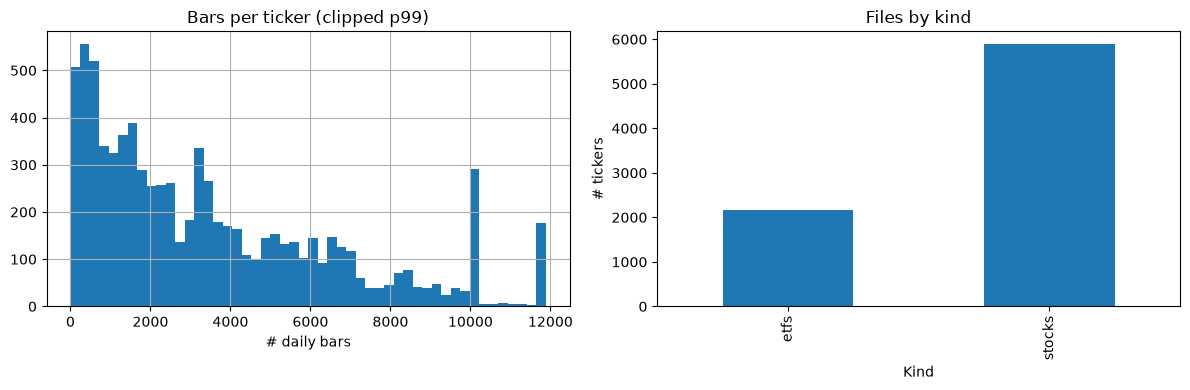

In [14]:
per_ticker = idx.assign(span_days=lambda x: (x["last"] - x["first"]).dt.days).sort_values(
    "rows", ascending=False
)
display(per_ticker.head(15))
display(idx.groupby("Kind").agg(files=("Ticker", "size"), rows=("rows", "sum")))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
per_ticker["rows"].clip(upper=per_ticker["rows"].quantile(0.99)).hist(bins=50, ax=axes[0])
axes[0].set_title("Bars per ticker (clipped p99)")
axes[0].set_xlabel("# daily bars")

idx.groupby("Kind").size().plot(kind="bar", ax=axes[1])
axes[1].set_title("Files by kind")
axes[1].set_ylabel("# tickers")
plt.tight_layout()
plt.show()

## Unique tickers by year

unique tickers: 8,049


,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
n_tickers,20,20,20,20,21,21,21,21,29,29,...,4595,4882,5208,5645,6019,6361,6809,7333,7939,8045
n_records,5040,5020,5060,5040,5165,5271,4746,5250,7366,7337,...,1119430,1184516,1260142,1357020,1451879,1540004,1625428,1756845,1911768,501557


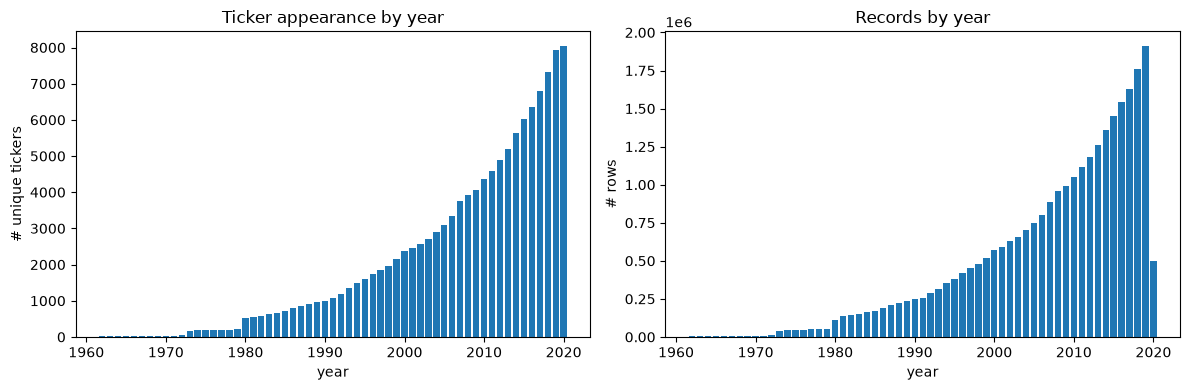

In [15]:
print(f"unique tickers: {idx['Ticker'].nunique():,}")
display(by_year.T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(by_year.index, by_year["n_tickers"], width=0.8)
axes[0].set_title("Ticker appearance by year")
axes[0].set_ylabel("# unique tickers")
axes[0].set_xlabel("year")

axes[1].bar(by_year.index, by_year["n_records"], width=0.8)
axes[1].set_title("Records by year")
axes[1].set_ylabel("# rows")
axes[1].set_xlabel("year")
plt.tight_layout()
plt.show()

## Sample prices

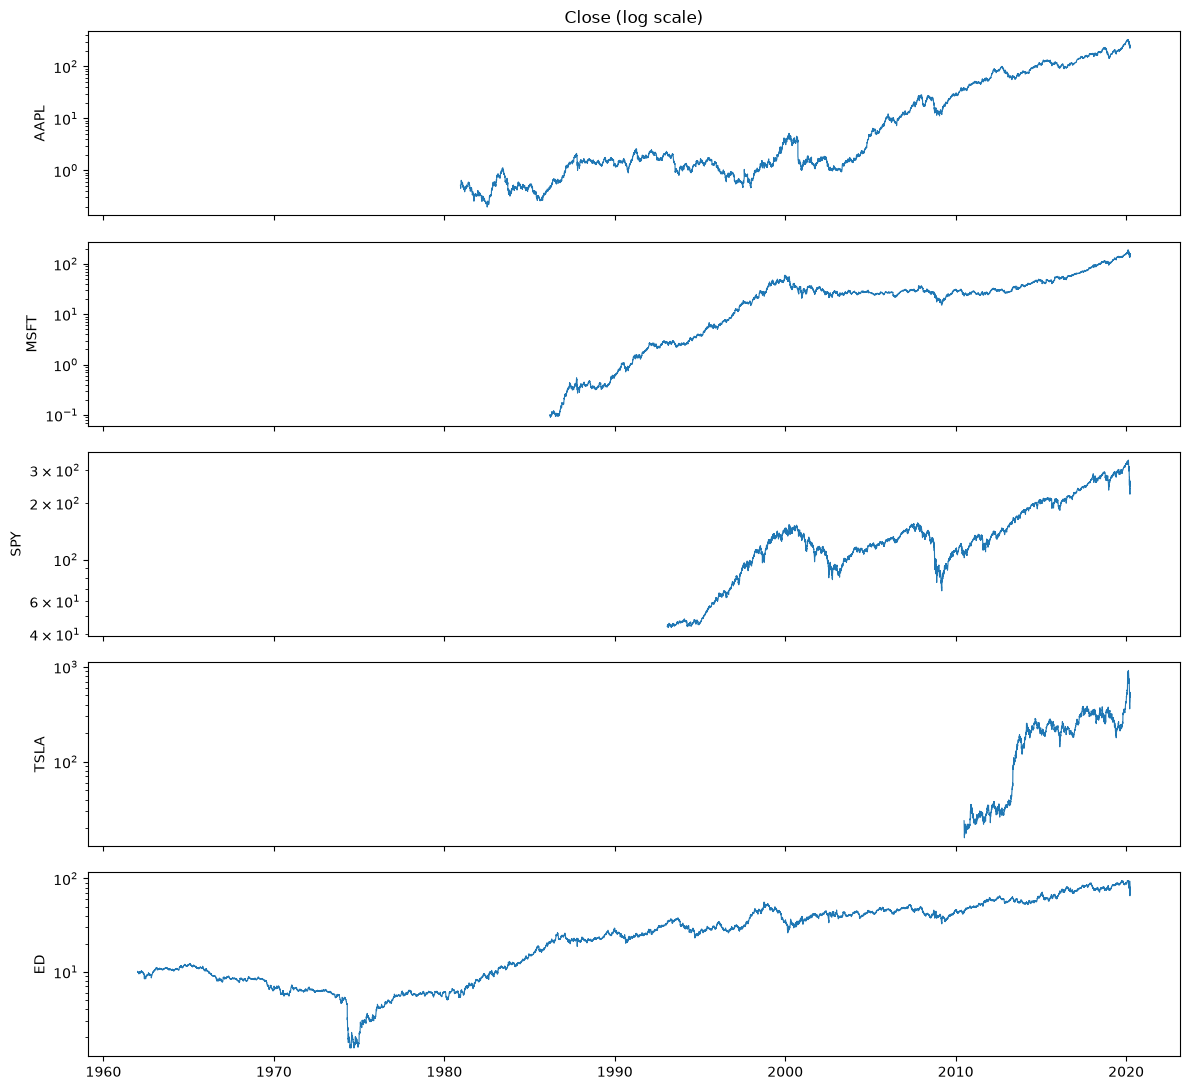

,first_date,last_date,bars,last_close
Ticker,,,,
AAPL,1980-12-12,2020-04-01,9909,240.910004
ED,1962-01-02,2020-04-01,14663,77.610001
MSFT,1986-03-13,2020-04-01,8584,152.110001
SPY,1993-01-29,2020-04-01,6843,246.149994
TSLA,2010-06-29,2020-04-01,2457,481.559998


In [16]:
SAMPLES = {
    "AAPL": "stocks/AAPL.csv",
    "MSFT": "stocks/MSFT.csv",
    "SPY": "etfs/SPY.csv",
    "TSLA": "stocks/TSLA.csv",
    "ED": "stocks/ED.csv",
}
sample = pd.concat(
    [load_csv(p, parse_dates=["Date"]).assign(Ticker=t) for t, p in SAMPLES.items()],
    ignore_index=True,
)

fig, axes = plt.subplots(len(SAMPLES), 1, figsize=(12, 2.2 * len(SAMPLES)), sharex=True)
for ax, t in zip(axes, SAMPLES):
    s = sample[sample["Ticker"] == t]
    ax.plot(s["Date"], s["Close"], lw=0.8)
    ax.set_ylabel(t)
    ax.set_yscale("log")
axes[0].set_title("Close (log scale)")
plt.tight_layout()
plt.show()

sample.groupby("Ticker").agg(
    first_date=("Date", "min"),
    last_date=("Date", "max"),
    bars=("Date", "size"),
    last_close=("Close", "last"),
)

## Metadata (`symbols_valid_meta.csv`)

NASDAQ **symbol directory** snapshot bundled with the dataset — one row per ticker in the price folders (~8k rows).

This is *not* price data. It maps each `Symbol` to human-readable name, listing venue, instrument type, and a few trading/status flags sourced from [nasdaqtrader.com](https://www.nasdaqtrader.com) symbol lists.

**12 columns:**

| Column | Role |
| --- | --- |
| `Nasdaq Traded` | Listed on NASDAQ system (always `Y` here) |
| `Symbol` | Primary ticker key — matches `{Symbol}.csv` filename |
| `Security Name` | Full company / fund name |
| `Listing Exchange` | Where the symbol primarily trades (`Q/N/P/Z/A`) |
| `Market Category` | NASDAQ tier for `Q`-listed names (`Q/G/S`, blank otherwise) |
| `ETF` | `Y` = ETF, `N` = stock/other |
| `Round Lot Size` | Standard board lot (usually 100 shares) |
| `Test Issue` | Test symbol flag (`N` for all rows here) |
| `Financial Status` | NASDAQ issuer status (`N/D/E/H`, blank if not NASDAQ-listed) |
| `CQS Symbol` | Consolidated quote system symbol (populated for non-`Q` listings) |
| `NASDAQ Symbol` | NASDAQ internal symbol (always populated) |
| `NextShares` | NextShares structure flag (`Y`/`N`) |

In [18]:
print(f"meta rows={len(meta):,}  columns={len(meta.columns)}")
display(meta.dtypes.to_frame("dtype"))
display(meta.head(8))

meta rows=8,049  columns=12


,dtype
Nasdaq Traded,str
Symbol,str
Security Name,str
Listing Exchange,str
Market Category,str
ETF,str
Round Lot Size,float64
Test Issue,str
Financial Status,str
CQS Symbol,str


,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N
5,Y,AAL,"American Airlines Group, Inc. - Common Stock",Q,Q,N,100.0,N,N,NaN,AAL,N
6,Y,AAMC,Altisource Asset Management Corp Com,A,,N,100.0,N,NaN,AAMC,AAMC,N
7,Y,AAME,Atlantic American Corporation - Common Stock,Q,G,N,100.0,N,N,NaN,AAME,N


### Identity columns

- **`Symbol`** — join key to price files (`stocks/AAPL.csv` ↔ `Symbol == AAPL`)
- **`Security Name`** — descriptive label (a few names repeat across different share classes)
- **`NASDAQ Symbol` / `CQS Symbol`** — alternate symbol identifiers; `CQS Symbol` is blank for pure NASDAQ (`Q`) listings

unique symbols=8,049  unique names=8,045
names shared by >1 symbol: 4


,symbols
Security Name,
MFS Municipal Income Trust Common Stock,2
Urstadt Biddle Properties Inc. Common Stock,2
iShares Edge MSCI Intl Size Factor ETF,2
iShares Morningstar Mid-Cap ETF,2
"voxeljet AG American Depositary Shares, each representing one-fifth of an ordinary share/",1
"1-800-FLOWERS.COM, Inc. - Class A Common Stock",1
"10x Genomics, Inc. - Common Stock",1
"111, Inc. - American Depositary Shares",1


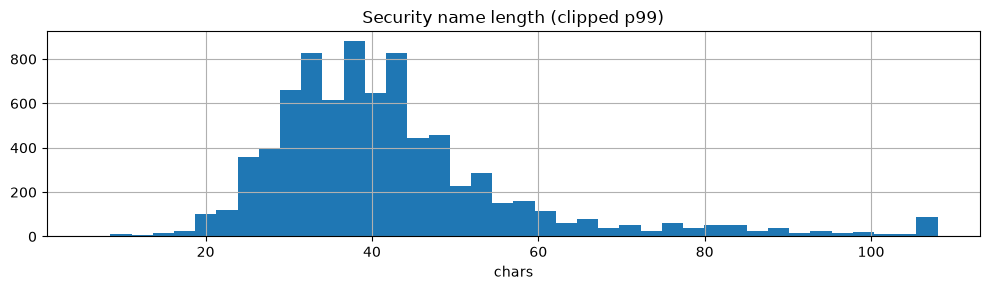

In [19]:
dup_names = meta.groupby("Security Name").size().sort_values(ascending=False)
print(f"unique symbols={meta['Symbol'].nunique():,}  unique names={meta['Security Name'].nunique():,}")
print(f"names shared by >1 symbol: {(dup_names > 1).sum()}")
display(dup_names.head(8).to_frame("symbols"))

fig, ax = plt.subplots(figsize=(10, 3))
meta["Security Name"].str.len().clip(upper=meta["Security Name"].str.len().quantile(0.99)).hist(bins=40, ax=ax)
ax.set_title("Security name length (clipped p99)")
ax.set_xlabel("chars")
plt.tight_layout()
plt.show()

### Listing exchange (`Listing Exchange`)

Where the symbol primarily trades:

| Code | Venue |
| --- | --- |
| `Q` | NASDAQ |
| `N` | NYSE |
| `P` | NYSE Arca |
| `Z` | Cboe BZX (BATS) |
| `A` | NYSE American (AMEX) |

Despite the dataset name, this is **not** NASDAQ-only — NYSE/Arca names are included too.

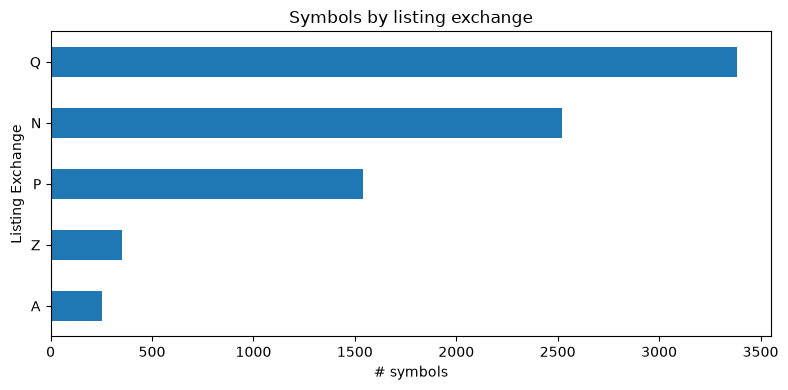

,count
Listing Exchange,
A,253
Z,351
P,1542
N,2520
Q,3383


In [20]:
ex = meta["Listing Exchange"].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
ex.plot(kind="barh", ax=ax)
ax.set_title("Symbols by listing exchange")
ax.set_xlabel("# symbols")
plt.tight_layout()
plt.show()
display(ex.to_frame("count"))

### Instrument type (`ETF`) and NASDAQ tier (`Market Category`)

- **`ETF`**: `Y` → file should live in `etfs/`; `N` → `stocks/`
- **`Market Category`**: only meaningful for `Listing Exchange == Q`
  - `Q` Global Select, `G` Global, `S` Capital Market, blank = not NASDAQ-tiered

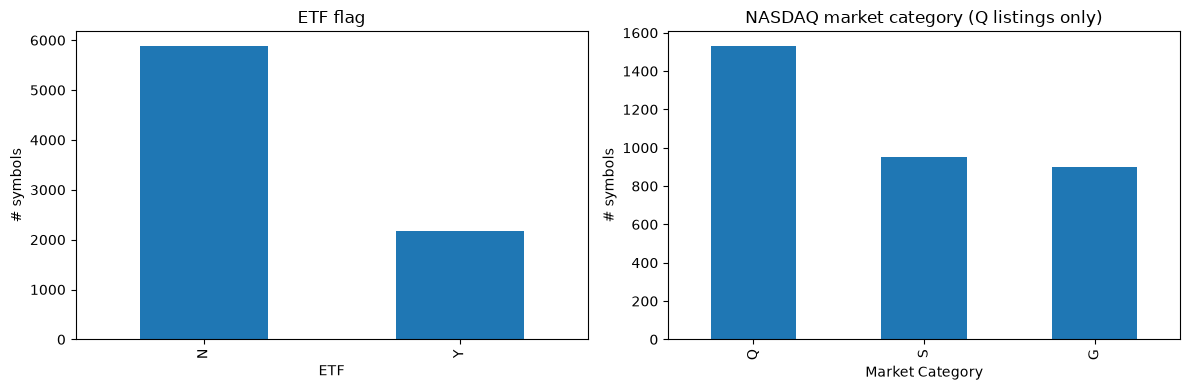

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
meta["ETF"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("ETF flag")
axes[0].set_ylabel("# symbols")

nasdaq = meta[meta["Listing Exchange"] == "Q"]
nasdaq["Market Category"].replace(" ", "(blank)").value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("NASDAQ market category (Q listings only)")
axes[1].set_ylabel("# symbols")
plt.tight_layout()
plt.show()

### Trading lot size (`Round Lot Size`)

Almost everything trades in **100-share** round lots. A handful of symbols use 10 or 1 (often lower-priced or special issues).

,count
Round Lot Size,
1.0,1
10.0,4
100.0,8044


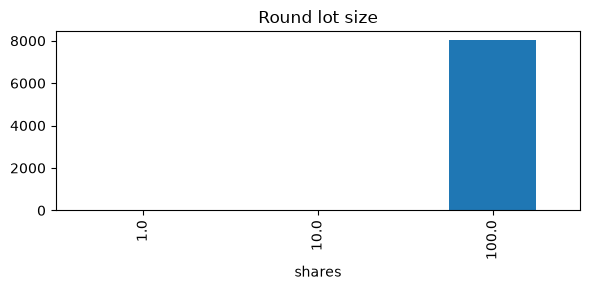

In [22]:
lots = meta["Round Lot Size"].value_counts().sort_index()
display(lots.to_frame("count"))
fig, ax = plt.subplots(figsize=(6, 3))
lots.plot(kind="bar", ax=ax)
ax.set_title("Round lot size")
ax.set_xlabel("shares")
plt.tight_layout()
plt.show()

### Status / flag columns

- **`Nasdaq Traded`**: `Y` for every row (this extract is the traded-symbol list)
- **`Test Issue`**: `N` for all — no test symbols included
- **`Financial Status`**: NASDAQ issuer health flag — only populated when `Listing Exchange == Q`
  - `N` normal, `D` deficient, `E` delinquent, `H` halted
- **`NextShares`**: exchange-traded managed fund structure — only 3 `Y` in this snapshot

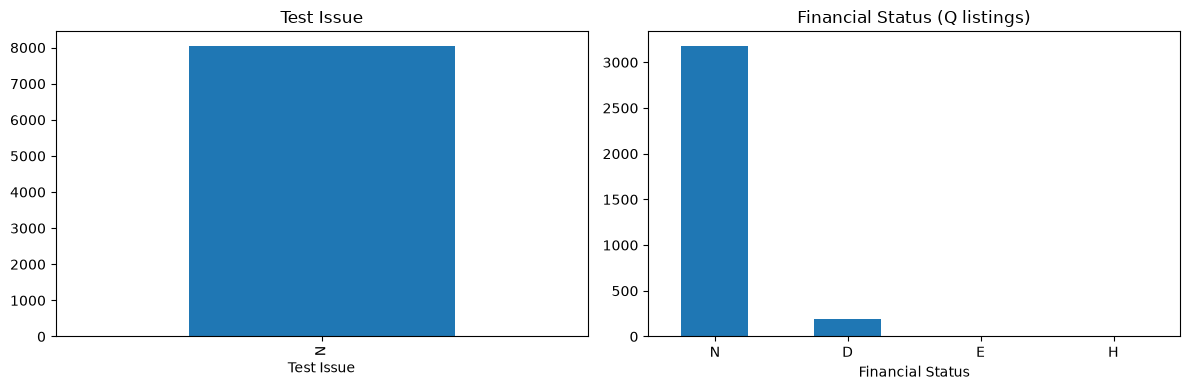

,count
NextShares,
N,8046
Y,3


,Symbol,Security Name
2344,EVGBC,Eaton Vance NextShares Trust - Eaton Vance Glo...
2350,EVLMC,Eaton Vance NextShares Trust II - Eaton Vance ...
2361,EVSTC,Eaton Vance NextShares Trust - Eaton Vance Sto...


In [23]:
nasdaq = meta[meta["Listing Exchange"] == "Q"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

meta["Test Issue"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Test Issue")

nasdaq["Financial Status"].fillna("(blank)").value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Financial Status (Q listings)")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

display(meta["NextShares"].value_counts().to_frame("count"))
display(meta.loc[meta["NextShares"] == "Y", ["Symbol", "Security Name"]])

### Metadata ↔ price files cross-check

Verify the directory lines up with what's on disk: symbol count, ETF split, and that each `Symbol` has a CSV in the expected folder.

In [24]:
meta_etfs = set(meta.loc[meta["ETF"] == "Y", "Symbol"])
meta_stocks = set(meta.loc[meta["ETF"] == "N", "Symbol"])
disk_etfs = {p.stem for p in Path("etfs").glob("*.csv")}
disk_stocks = {p.stem for p in Path("stocks").glob("*.csv")}

print(f"meta symbols={len(meta):,}  disk files={len(disk_etfs | disk_stocks):,}")
print(f"ETF  meta={len(meta_etfs):,} disk={len(disk_etfs):,}  only meta={len(meta_etfs - disk_etfs):,}  only disk={len(disk_etfs - meta_etfs):,}")
print(f"stock meta={len(meta_stocks):,} disk={len(disk_stocks):,}  only meta={len(meta_stocks - disk_stocks):,}  only disk={len(disk_stocks - meta_stocks):,}")

mismatch = meta[~meta["Symbol"].isin(disk_etfs | disk_stocks)]
if len(mismatch):
    display(mismatch[["Symbol", "ETF", "Listing Exchange", "Security Name"]].head(10))

meta symbols=8,049  disk files=8,049
ETF  meta=2,165 disk=2,165  only meta=0  only disk=0
stock meta=5,884 disk=5,884  only meta=3  only disk=3


,Symbol,ETF,Listing Exchange,Security Name
162,AGM$A,N,N,Federal Agricultural Mortgage Corporation 5.87...
1068,CARR.V,N,N,Carrier Global Corporation Common Stock When I...
7457,UTX.V,N,N,United Technologies Corporation Common Stock E...
